In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import shutil
import os

In [2]:
path=kagglehub.dataset_download("sbhatti/financial-sentiment-analysis")
print(f"path : {path}")
custom_path="..\Datasets\original_dataset"
shutil.copytree(path,custom_path,dirs_exist_ok=True)

path : C:\Users\DELL\.cache\kagglehub\datasets\sbhatti\financial-sentiment-analysis\versions\4


'..\\Datasets\\original_dataset'

In [3]:
csv_path=os.path.join(custom_path,"data.csv")
df=pd.read_csv(csv_path)
df.head()

,Sentence,Sentiment
0,The GeoSolutions technology will leverage Bene...,positive
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative
2,"For the last quarter of 2010 , Componenta 's n...",positive
3,According to the Finnish-Russian Chamber of Co...,neutral
4,The Swedish buyout firm has sold its remaining...,neutral


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5842 entries, 0 to 5841
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Sentence   5842 non-null   object
 1   Sentiment  5842 non-null   object
dtypes: object(2)
memory usage: 91.4+ KB


In [5]:
df.isnull().sum()

Sentence     0
Sentiment    0
dtype: int64

In [6]:
df['Sentiment'].value_counts()

Sentiment
neutral     3130
positive    1852
negative     860
Name: count, dtype: int64

In [7]:
df['Sentiment']=df['Sentiment'].map({
    'neutral':0,
    'positive':1,
    'negative':2
})

In [8]:
df.head()

,Sentence,Sentiment
0,The GeoSolutions technology will leverage Bene...,1
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",2
2,"For the last quarter of 2010 , Componenta 's n...",1
3,According to the Finnish-Russian Chamber of Co...,0
4,The Swedish buyout firm has sold its remaining...,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5842 entries, 0 to 5841
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Sentence   5842 non-null   object
 1   Sentiment  5842 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 91.4+ KB


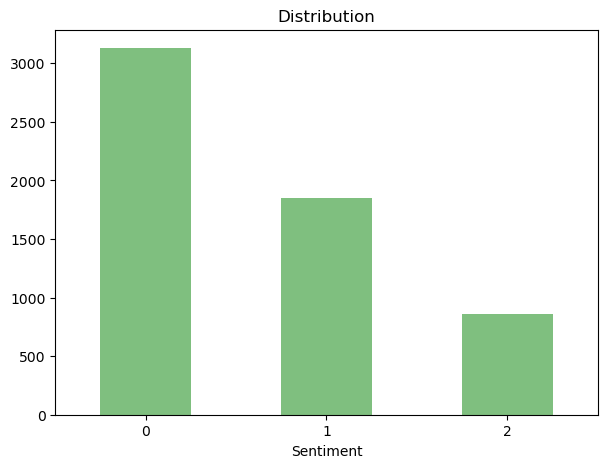

In [10]:
plt.figure(figsize=(7,5))
df['Sentiment'].value_counts().plot(kind='bar',color='green',alpha=0.50)
plt.title("Distribution")
plt.xticks(rotation=0)
plt.show()

In [11]:
for i in range(0,3):
    sample=df[df['Sentiment']==i]['Sentence'].iloc[0]
    print(f"{i} sentiment")
    print(f"{sample}\n")

0 sentiment
According to the Finnish-Russian Chamber of Commerce , all the major construction companies of Finland are operating in Russia .

1 sentiment
The GeoSolutions technology will leverage Benefon 's GPS solutions by providing Location Based Search Technology , a Communities Platform , location relevant multimedia content and a new and powerful commercial model .

2 sentiment
$ESI on lows, down $1.50 to $2.50 BK a real possibility



In [12]:
df['text_len']=df['Sentence'].str.len()
df['word_count']=df['Sentence'].str.split().str.len()

In [13]:
df.head()

,Sentence,Sentiment,text_len,word_count
0,The GeoSolutions technology will leverage Bene...,1,218,32
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",2,55,11
2,"For the last quarter of 2010 , Componenta 's n...",1,193,39
3,According to the Finnish-Russian Chamber of Co...,0,128,20
4,The Swedish buyout firm has sold its remaining...,0,135,23


In [14]:
neg_pct=(len(df[df['Sentiment']==2])/len(df))*100
print(f"Negative Comments :{neg_pct:.2f}%")
pos_pct=(len(df[df['Sentiment']==1])/len(df))*100
print(f"Positive Comments :{pos_pct:.2f}%")
neu_pct=(len(df[df['Sentiment']==0])/len(df))*100
print(f"Neutral Comments :{neu_pct:.2f}%")

Negative Comments :14.72%
Positive Comments :31.70%
Neutral Comments :53.58%


In [15]:
import re

def clean_text(text):
    text=text.lower()
    text=re.sub(r'[^a-zA-Z0-9\s]','',text)
    text=' '.join(text.split())
    return text
print(clean_text("Hi how are YOu 8nsc8# *&)# , but IHND "))

hi how are you 8nsc8 but ihnd


In [16]:
df['clean_text']=df['Sentence'].apply(clean_text)

In [17]:
df.head()

,Sentence,Sentiment,text_len,word_count,clean_text
0,The GeoSolutions technology will leverage Bene...,1,218,32,the geosolutions technology will leverage bene...
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",2,55,11,esi on lows down 150 to 250 bk a real possibility
2,"For the last quarter of 2010 , Componenta 's n...",1,193,39,for the last quarter of 2010 componenta s net ...
3,According to the Finnish-Russian Chamber of Co...,0,128,20,according to the finnishrussian chamber of com...
4,The Swedish buyout firm has sold its remaining...,0,135,23,the swedish buyout firm has sold its remaining...


In [18]:
X=df['clean_text']
y=df['Sentiment']

In [19]:
X.head()

0    the geosolutions technology will leverage bene...
1    esi on lows down 150 to 250 bk a real possibility
2    for the last quarter of 2010 componenta s net ...
3    according to the finnishrussian chamber of com...
4    the swedish buyout firm has sold its remaining...
Name: clean_text, dtype: object

In [20]:
y.head()

0    1
1    2
2    1
3    0
4    0
Name: Sentiment, dtype: int64

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import load_model,Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense,Dropout,SimpleRNN,LSTM,Embedding
from tensorflow.keras.callbacks import EarlyStopping
import pickle
import warnings
warnings.filterwarnings('ignore')

In [22]:
max_features=10000
max_len=150

tokenizer=Tokenizer(num_words=max_features,oov_token='<OOV>')
tokenizer.fit_on_texts(X)
X_sequences=tokenizer.texts_to_sequences(X)

In [23]:
X_sequences[0]

[2,
 4033,
 110,
 14,
 3132,
 1464,
 10,
 1965,
 105,
 19,
 773,
 1252,
 218,
 2235,
 110,
 7,
 3133,
 1173,
 1252,
 1966,
 3134,
 631,
 6,
 7,
 47,
 6,
 4034,
 540,
 436]

In [24]:
X_padded=pad_sequences(X_sequences,maxlen=max_len,padding='post',truncating='post')

In [25]:
x_train,x_test,y_train,y_test=train_test_split(X_padded,y,train_size=0.75,stratify=y,random_state=42)

In [26]:
class_weights=compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights=dict(enumerate(class_weights))
class_weights

{0: np.float64(0.6222127538701889),
 1: np.float64(1.0513558915286778),
 2: np.float64(2.2640826873385014)}

In [27]:
def create_RNN_model():
    model=Sequential([
        Embedding(input_dim=max_features,output_dim=128,input_length=max_len),
        SimpleRNN(units=64,return_sequences=False),
        Dropout(0.5),
        Dense(64,activation='relu'),
        Dense(32,activation='relu'),
        Dense(16,activation='relu'),
        Dense(3,activation='softmax')
    ])
    return model
rnn_model=create_RNN_model()
rnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [28]:
rnn_history=rnn_model.fit(
    x_train,y_train,
    batch_size=32,
    epochs=8,
    validation_split=0.20,
    class_weight=class_weights
)

Epoch 1/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 17s 71ms/step - accuracy: 0.2965 - loss: 1.1034 - val_accuracy: 0.1437 - val_loss: 1.1110
Epoch 2/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 8s 68ms/step - accuracy: 0.2922 - loss: 1.1100 - val_accuracy: 0.1437 - val_loss: 1.1555
Epoch 3/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 7s 66ms/step - accuracy: 0.2734 - loss: 1.1095 - val_accuracy: 0.4208 - val_loss: 1.0909
Epoch 4/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 7s 64ms/step - accuracy: 0.3553 - loss: 1.1010 - val_accuracy: 0.1756 - val_loss: 1.1067
Epoch 5/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 7s 64ms/step - accuracy: 0.3208 - loss: 1.1024 - val_accuracy: 0.2064 - val_loss: 1.1125
Epoch 6/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - accuracy: 0.2648 - loss: 1.1001 - val_accuracy: 0.3113 - val_loss: 1.0955
Epoch 7/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 11s 68ms/step - accuracy: 0.3008 - loss: 1.1011 - val_accuracy: 0.1425 - val_loss: 1.1068
Epoch 8/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - accuracy: 0.2143 - loss: 1.1008 - val_accuracy:

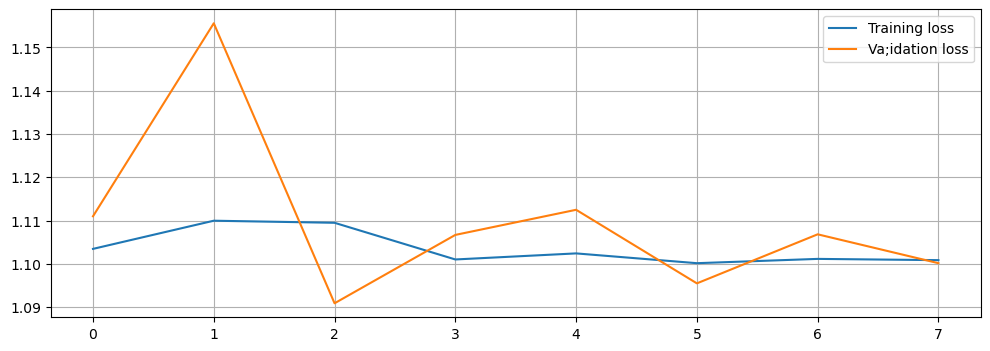

In [29]:
plt.figure(figsize=(12,4))
plt.plot(rnn_history.history['loss'],label="Training loss")
plt.plot(rnn_history.history['val_loss'],label="Va;idation loss")
plt.legend()
plt.grid()

In [30]:
def create_LSTM_model():
    model=Sequential([
        Embedding(input_dim=max_features,output_dim=128,input_length=max_len),
        LSTM(units=64,return_sequences=False),
        Dropout(0.5),
        Dense(64,activation='relu'),
        Dense(32,activation='relu'),
        Dense(16,activation='relu'),
        Dense(3,activation='softmax')
    ])
    return model
lstm_model=create_LSTM_model()
lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [31]:
lstm_history=lstm_model.fit(
    x_train,y_train,
    batch_size=32,
    epochs=8,
    validation_split=0.20,
    class_weight=class_weights
)

Epoch 1/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 22s 125ms/step - accuracy: 0.3042 - loss: 1.1007 - val_accuracy: 0.1437 - val_loss: 1.1231
Epoch 2/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 13s 117ms/step - accuracy: 0.2763 - loss: 1.1008 - val_accuracy: 0.5348 - val_loss: 1.0963
Epoch 3/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 13s 118ms/step - accuracy: 0.3353 - loss: 1.1003 - val_accuracy: 0.3216 - val_loss: 1.0998
Epoch 4/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 21s 122ms/step - accuracy: 0.2152 - loss: 1.1000 - val_accuracy: 0.3216 - val_loss: 1.0984
Epoch 5/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 13s 117ms/step - accuracy: 0.2517 - loss: 1.0999 - val_accuracy: 0.5348 - val_loss: 1.0976
Epoch 6/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 13s 113ms/step - accuracy: 0.4244 - loss: 1.0999 - val_accuracy: 0.1437 - val_loss: 1.0988
Epoch 7/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 20s 110ms/step - accuracy: 0.1841 - loss: 1.1001 - val_accuracy: 0.1437 - val_loss: 1.0988
Epoch 8/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 11s 97ms/step - accuracy: 0.3245 - loss: 1.0998 - v

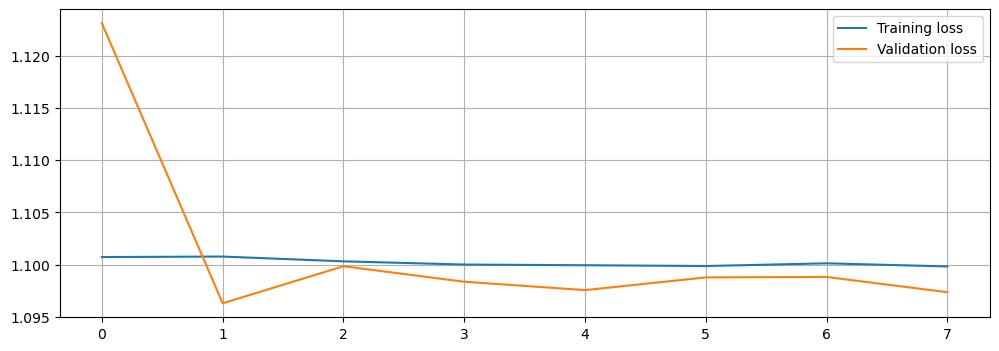

In [70]:
plt.figure(figsize=(12,4))
plt.plot(lstm_history.history['loss'],label="Training loss")
plt.plot(lstm_history.history['val_loss'],label="Validation loss")
plt.legend()
plt.grid()

In [42]:
def save_model(model,model_name):
    path=os.path.join("..\Models",model_name+".keras")
    with open(path,'wb') as file:
        model.save(path)

In [43]:
save_model(lstm_model,"lstm_model")

In [44]:
def load_saved_model(model):
    path=os.path.join("..\Models",model+".keras")
    if not os.path.exists(path):
        print("model doesnot exist")
        return None
    return load_model(path)

In [46]:
lstm_model=load_saved_model("lstm_model")

In [47]:
save_model(rnn_model,"rnn_model")

In [52]:
with open(r"..\Models\tokenizer.pkl","wb") as file:
    pickle.dump(tokenizer,file)

In [53]:
with open(r"..\Models\max_len.pkl","wb") as file:
    pickle.dump(max_len,file)

In [55]:
with open(r"..\Models\tokenizer.pkl","rb") as file:
    t=pickle.load(file)
with open(r"..\Models\max_len.pkl","rb") as file:
    max_len=pickle.load(file)

In [68]:
def predict_sentiment(text):
    cleaned_txt=clean_text(text)
    sequence=t.texts_to_sequences([cleaned_txt])
    padded_txt=pad_sequences(sequence,maxlen=max_len)

    prediction=lstm_model.predict(padded_txt)
    predicted_class = np.argmax(prediction)
    sentiment_map = {
        0: "Neutral",
        1: "Positive",
        2: "Negative"
    }

    print("Prediction:", prediction)
    print("Sentiment:", sentiment_map[predicted_class])

In [69]:
predict_sentiment("we gained profit")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
Prediction: [[0.33492598 0.33224985 0.33282408]]
Sentiment: Neutral
